# Figure 7 — Trotter decomposition of one controlled evolution

**Paper location:** Appendix E.1, Fig. 7. **Requires Qiskit.**

## What this figure shows

How one Rodeo controlled evolution `e^{±iM τ}` reduces to elementary gates, connecting
the dense circuit of Fig. 6 to the `(2N+1)^k` gate-cost model. In the Pauli basis the
single-spin embedding is a sum of **nine** strings; first-order Trotterization writes the
controlled evolution as the ordered product of the nine single-term evolutions
`e^{-iθ_P P}`. (For this `M` a single second-order Trotter step already matches the dense
unitary to machine precision.)

## Model & construction

| | |
|---|---|
| **Embedding** | single-spin `M`, decomposed as `M = Σ_P c_P P` |
| **Pauli terms** | nine: `XII, XIZ, XXX, XYY, XZI, YIX, YXI, YXY, YYX` |
| **Per term** | basis change → CNOT ladder → `R_z` phase → uncompute ladder |


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))
import numpy as np
import rodeo_ness as rn
from scipy.linalg import expm
try:
    import qiskit
    from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
    from qiskit.circuit.library import UnitaryGate
    HAVE_QISKIT = True
    print("Qiskit", qiskit.__version__)
except Exception as e:
    HAVE_QISKIT = False
    print("Qiskit not available:", e)


Qiskit 2.4.2


### Decompose M into Pauli terms and draw the Trotter product

M = 9 Pauli terms: XII, XIZ, XXX, XYY, XZI, YIX, YXI, YXY, YYX


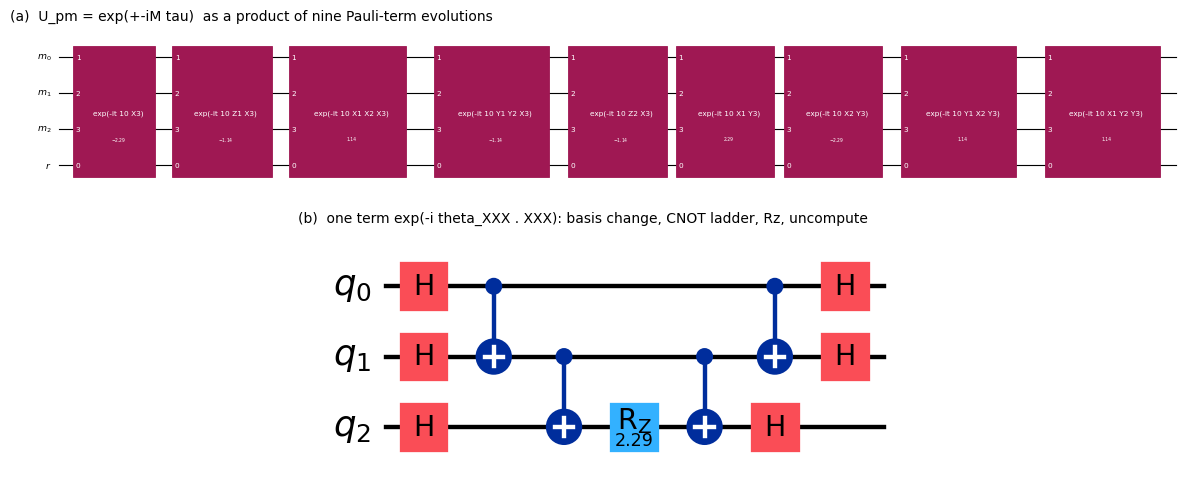

In [2]:
assert HAVE_QISKIT, "install qiskit"
import matplotlib.pyplot as plt
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import PauliEvolutionGate

M = rn.hermitian_embedding(rn.single_spin_liouvillian(h=0.5))
times = rn.vdc_schedule(2, 8.0); tau = times[0]

# --- (a) the controlled evolution as a product of nine Pauli-term evolutions ---
sp = SparsePauliOp.from_operator(M)
terms = [(p, c.real) for p,c in zip(sp.paulis, sp.coeffs) if abs(c.real)>1e-9]
print("M =", len(terms), "Pauli terms:", ", ".join(str(p) for p,_ in terms))
m2=QuantumRegister(3,"m"); r2=QuantumRegister(1,"r")
qc_a=QuantumCircuit(m2,r2)
for p,c in terms:
    qc_a.append(PauliEvolutionGate(SparsePauliOp([p],[1.0]),time=c*tau).control(1),[r2[0]]+list(m2))

# --- (b) one term (XXX) expanded into elementary gates ---
theta = (dict((str(p),c) for p,c in terms)).get("XXX", 0.25) * tau
qb = QuantumRegister(3,"q")
qc_b = QuantumCircuit(qb)
for i in range(3): qc_b.h(qb[i])          # Hadamard basis change U=H
qc_b.cx(qb[0],qb[1]); qc_b.cx(qb[1],qb[2])  # CNOT ladder
qc_b.rz(2*theta, qb[2])                     # Rz phase rotation P
qc_b.cx(qb[1],qb[2]); qc_b.cx(qb[0],qb[1])  # uncompute ladder
for i in range(3): qc_b.h(qb[i])

# draw both panels stacked
fig, (axa, axb) = plt.subplots(2, 1, figsize=(12, 5),
                               gridspec_kw={"height_ratios":[1, 1.1]})
qc_a.draw("mpl", fold=-1, ax=axa)
axa.set_title("(a)  U_pm = exp(+-iM tau)  as a product of nine Pauli-term evolutions", fontsize=10, loc="left")
qc_b.draw("mpl", fold=-1, ax=axb)
axb.set_title("(b)  one term exp(-i theta_XXX . XXX): basis change, CNOT ladder, Rz, uncompute", fontsize=10, loc="left")
fig.tight_layout()
fig.savefig("rodeo_trotter_decomp.pdf", bbox_inches="tight")
plt.show()